In [2]:
import pandas as pd

# Load red and white wine datasets from UCI Machine Learning Repository
url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

df_red = pd.read_csv(url_red, sep=';')
df_white = pd.read_csv(url_white, sep=';')
df_red['wine_type'] = 'red'
df_white['wine_type'] = 'white'
df_wine = pd.concat([df_red, df_white], axis=0, ignore_index=True)

df_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [3]:
import numpy as np
from scipy import stats
from typing import Optional, Sequence

def wine_stats(df_wine: pd.DataFrame, *, group_cols: Optional[Sequence[str]] = None,
               kurtosis: str = "excess", # "excess" (normal = 0) or "pearson" (normal = 3)
               round_digits: int = 3) -> pd.DataFrame:
    
    df = df_wine.copy()
    group_cols = list(group_cols) if group_cols is not None else ["quality"]

    # guards
    for gc in group_cols:
        if gc not in df.columns:
            raise ValueError(f"Group column '{gc}' not found in DataFrame.")

    # numeric features only (exclude grouping vars)
    num_cols = df.select_dtypes(include = [np.number]).columns.tolist()
    feature_cols = [c for c in num_cols if c not in group_cols]

    rows = []

    def clean(x):
        return np.asarray(pd.Series(x).dropna(), dtype = float)

    def row_stats(arr):
        if arr.size == 0:
            return dict(Minimum = np.nan, Maximum = np.nan, Mean = np.nan, Std = np.nan,
                        **{"Trimmed Mean (5%)": np.nan}, Skewness = np.nan, Kurtosis = np.nan)
            
        use_fisher = (kurtosis.lower() != "pearson")  # True then excess kurtosis
        
        return {
            "Minimum": np.min(arr),
            "Maximum": np.max(arr),
            "Mean":    np.mean(arr),
            "Std":     np.std(arr, ddof = 1),  # sample std
            "Trimmed Mean (5%)": stats.trim_mean(arr, 0.05),
            "Skewness": stats.skew(arr, bias = False),
            "Kurtosis": stats.kurtosis(arr, fisher = use_fisher, bias = False),
        }

    # overall (no grouping)
    for feat in feature_cols:
        arr = clean(df[feat])
        base = {"scope": "overall", "feature": feat}
        # add NaN for each group column
        for gc in group_cols:
            base[gc] = np.nan
        rows.append({**base, **row_stats(arr)})

    # grouped by group_cols
    for keys, g in df.groupby(group_cols):
        # keys is a scalar if one group col
        if not isinstance(keys, tuple):
            keys = (keys,)
            
        group_vals = dict(zip(group_cols, keys))
        
        for feat in feature_cols:
            arr = clean(g[feat])
            row = {"scope": "grouped", "feature": feat, **group_vals, **row_stats(arr)}
            rows.append(row)

    out = pd.DataFrame(rows)
    numeric_cols = ["Minimum", "Maximum", "Mean", "Std", "Trimmed Mean (5%)", "Skewness", "Kurtosis"]
    out[numeric_cols] = out[numeric_cols].round(round_digits)
    return out

table = wine_stats(df_wine, group_cols=["quality", "wine_type"], kurtosis = "excess")

print("\n=== Feature Statistics Grouped by Wine Quality Rating and Wine Type ===")
print(table[table["scope"] == "grouped"].to_string(index = False))


=== Feature Statistics Grouped by Wine Quality Rating and Wine Type ===
  scope              feature  quality wine_type  Minimum  Maximum    Mean     Std  Trimmed Mean (5%)  Skewness  Kurtosis
grouped        fixed acidity      3.0       red    6.700   11.600   8.360   1.771              8.360     0.953    -0.715
grouped     volatile acidity      3.0       red    0.440    1.580   0.884   0.331              0.885     0.871     1.029
grouped          citric acid      3.0       red    0.000    0.660   0.171   0.251              0.171     1.229    -0.170
grouped       residual sugar      3.0       red    1.200    5.700   2.635   1.402              2.635     1.408     1.433
grouped            chlorides      3.0       red    0.061    0.267   0.123   0.066              0.123     1.396     1.345
grouped  free sulfur dioxide      3.0       red    3.000   34.000  11.000   9.764             11.000     1.732     2.775
grouped total sulfur dioxide      3.0       red    9.000   49.000  24.900  16.82

#### **Data Interpretation** 
Both red and white wines show the same pattern. When the quality score goes up, the alcohol level rises and things like acidity, sugar, and chlorides go down. That means the better wines are usually drier and more balanced. <br>

White wines typically start with higher residual sugar and sulfur dioxide and slightly lower pH (more acidic), so a higher quality white wine is still relatively drier/cleaner even within just white wines. Red wines often show higher volatile and fixed acidity and slightly higher pH, and their better bottles cluster at lower volatile acidity, more controlled sulfur dioxide, and moderately higher alcohol. <br>

So basically, no matter the type, better wines have more alcohol and less sugar or acidity overall. When both red and white wines are combined, white wines generally rate higher on average in the dataset, with more consistency across chemical features. Red wines can reach equally high quality when well-balanced (especially when alcohol is high and volatile acidity is low), but their broader chemistry range introduces more variability and outliers.

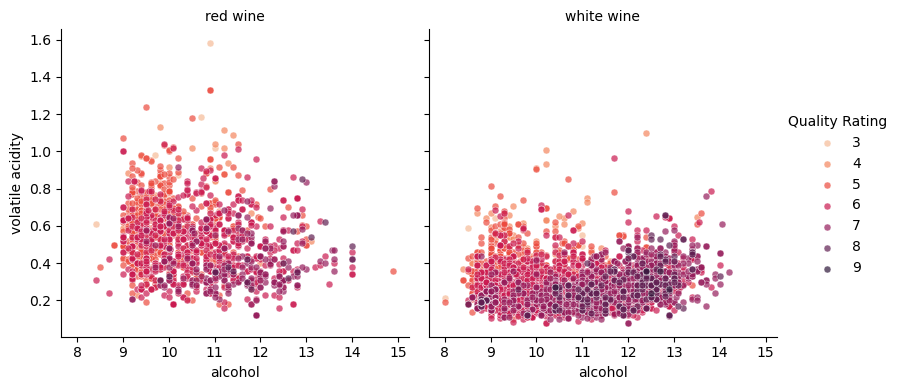

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# picked volatile_acidity and alcohol as they have shown distinct trends with wine quality
g = sns.FacetGrid(df_wine, col = "wine_type", hue = "quality", palette = "rocket_r", height = 4)
g.map_dataframe(sns.scatterplot, x = "alcohol", y = "volatile acidity", alpha = 0.7, s = 25)
g.add_legend(title = "Quality Rating")
g.set_titles("{col_name} wine")
plt.show()

#### **Patterns and Trends**
The alcohol vs volatile acidity plot shows that when one goes up, the other goes down. There are clusters forming that match the wine quality levels. The points form a downward trend, showing that as alcohol content increases, volatile acidity decreases, and the quality of the wine improves. Wines with higher quality ratings (quality of 7 to 9) are clustered toward the lower right region (high alcohol, low volatile acidity), while those with lower quality ratings (quality of 3 to 5) are positioned in the upper left region (low alcohol, high volatile acidity). Wines of mid level quality (quality of 5 to 6) are more spread out and overlap both areas, suggesting a gradual chemical transition rather than a strict separation.

This trend holds true for both red and white wines, though each type has its own chemical profile. Red wines generally have higher volatile acidity and slightly higher fixed acidity, giving them a sharper flavor baseline, whereas white wines tend to show lower volatile acidity, higher residual sugar, and greater sulfur dioxide levels, which make them naturally crisper and cleaner. Still, within each type, the same pattern appears where higher quality wines consistently have higher alcohol, lower volatile acidity, and less variation across their chemical features.

These observations are also supported by winemaking research, such as GuildSomm [3][4], which notes that high volatile acidity produces undesirable sour or vinegary notes, while higher alcohol levels enhance a wine’s body, richness, and smoothness. So basically, high alcohol and low volatile acidity are the best combo for good wine, that balance makes the flavor smoother and cleaner. <br>

#### **Quality Separating Features**
Beyond alcohol and volatile acidity, other features such as chlorides, residual sugar, and density also help distinguish wine quality levels, as seen in the descriptive statistics. Higher-quality wines tend to be drier (lower residual sugar), have fewer mineral impurities (lower chlorides), and exhibit lower density, which reflects the balance between higher alcohol and lower sugar content.
While these additional features support the broader quality trends, alcohol remains the most consistent positive indicator, and volatile acidity remains the strongest negative indicator, across both red and white wines. Together, these two features provide the clearest and most reliable chemical markers for differentiating between higher and lower quality wines in the dataset.

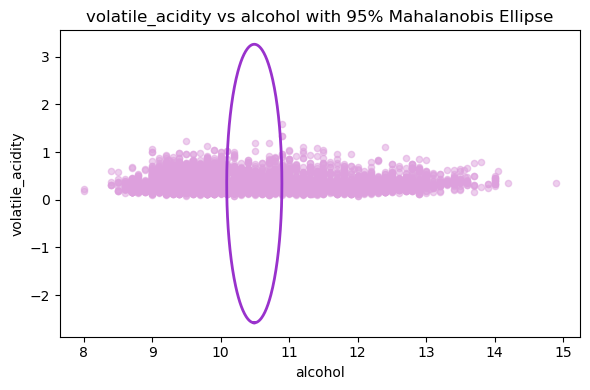

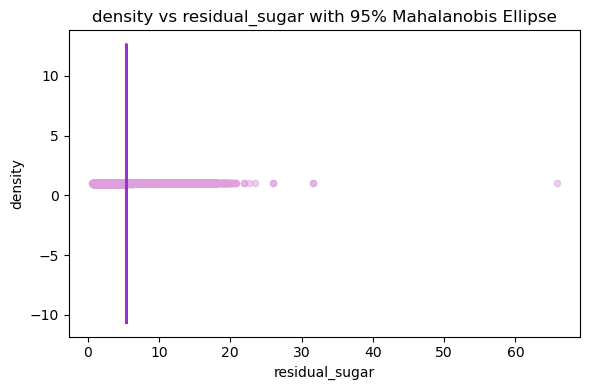

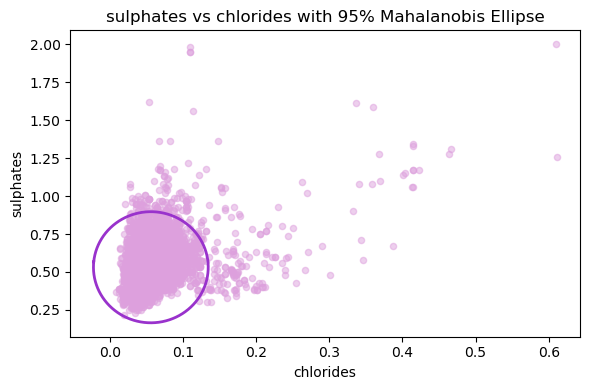


Detected 249 outliers out of 6497 samples (3.83%).


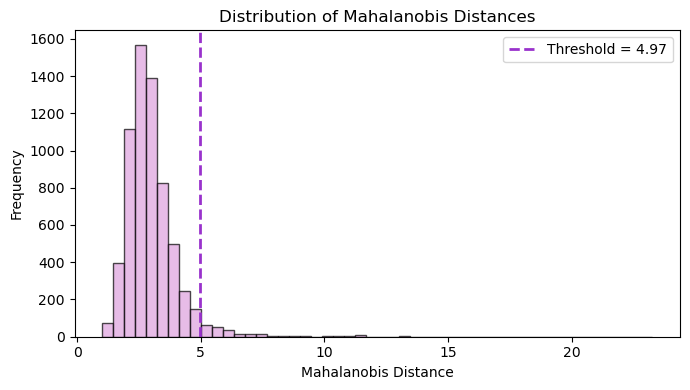

In [25]:
from scipy.stats import chi2

# make a clean copy and standardize column names
df = df_wine.copy()
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# three pairs of numerical features for ellipse plots
feature_pairs = [("alcohol", "volatile_acidity"),
                 ("residual_sugar", "density"),
                 ("chlorides", "sulphates")
                ]

# draws a scatter plot for two variables and overlays a Mahalanobis ellipse. 
# the ellipse represents the 95% confidence boundary for bivariate normal data.
# points outside the ellipse are likely multivariate outliers.
def plot_mahalanobis_ellipse(df, xcol, ycol, level = 0.95):

    X = df[[xcol, ycol]].dropna().to_numpy()

    # compute mean vector and covariance matrix
    mu = X.mean(axis = 0)
    cov = np.cov(X, rowvar = False)
    
    # add a small diagonal value to covariance to prevent singularity
    # (especially for highly correlated features like sugar and density)
    cov += np.eye(cov.shape[0]) * 1e-6  

    inv_cov = np.linalg.inv(cov)

    # chi-square cutoff for 2D data
    c2 = chi2.ppf(level, df = 2)

    # create ellipse points
    vals, vecs = np.linalg.eigh(cov)
    radii = np.sqrt(vals * c2)
    t = np.linspace(0, 2 * np.pi, 300)
    circle = np.stack([np.cos(t), np.sin(t)], axis = 1)
    ellipse = circle @ (vecs * radii) + mu

    # plot
    plt.figure(figsize = (6, 4))
    plt.scatter(X[:, 0], X[:, 1],  color = "plum", alpha = 0.5, s = 20)
    plt.plot(ellipse[:, 0], ellipse[:, 1], color = "darkorchid", lw = 2)
    plt.title(f"{ycol} vs {xcol} with 95% Mahalanobis Ellipse")
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.tight_layout()
    plt.show()

# draw ellipses for each feature pair
for (a, b) in feature_pairs:
    plot_mahalanobis_ellipse(df, a, b)

# computes the Mahalanobis distance for each observation across multiple correlated numeric features.
def mahalanobis_distances(df, feature_cols):

    X = df[feature_cols].dropna()
    mu = X.mean(axis = 0)
    cov = np.cov(X.values, rowvar = False)
    cov += np.eye(cov.shape[0]) * 1e-6 # regularization for safety
    inv_cov = np.linalg.inv(cov)
    diffs = X - mu
    md_squared = np.einsum('ij,jk,ik->i', diffs, inv_cov, diffs)
    return pd.Series(np.sqrt(md_squared), index = X.index)

num_cols = df.select_dtypes(np.number).columns.tolist()
feature_cols = [c for c in num_cols if c not in ['quality']]

# compute distances
df['mahalanobis'] = mahalanobis_distances(df, feature_cols)

# determine threshold for extreme points based on Chi-square cutoff
k = len(feature_cols) # number of dimensions
threshold = np.sqrt(chi2.ppf(0.99, df = k)) # 99% confidence interval
outliers = df[df['mahalanobis'] > threshold]
clean_df = df[df['mahalanobis'] <= threshold]

print(f"\nDetected {len(outliers)} outliers out of {len(df)} samples ({100*len(outliers)/len(df):.2f}%).")

# visualize distribution of Mahalanobis distances
plt.figure(figsize=(7,4))
plt.hist(df['mahalanobis'], bins = 50, color = 'plum', edgecolor = 'black', alpha = 0.7)
plt.axvline(threshold, color = 'darkorchid', linestyle = '--', linewidth = 2, label = f"Threshold = {threshold:.2f}")
plt.title("Distribution of Mahalanobis Distances")
plt.xlabel("Mahalanobis Distance")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

#### **Justification in choice of threshold**
Using the 99% cutoff works well because it only removes a few extreme points and keeps most of the normal data. With thousands of rows, a looser cutoff like 95% could throw away a lot of potentially viable observations (false positives), and a tighter one like 99.9% would leave in too many potential outliers (false negatives). Either one would skew averages, correlations, and models. The 99% line is a balanced threshold that avoids both situations and it even matches what is seen in the plots where the main cloud sits well inside the boundary, and the points beyond it are clearly outliers. <br>

#### **Why Mahalanobis distance is appropriate for multivariate data?**
Mahalanobis distance is a multi feature distance that accounts for different units (percent vs g/L) and for features that move together (like sugar and density). It effectively levels the playing field and assesses if and how unusual a combination of values is compared with the rest. That’s how it is able to catch odd combinations that a plain Euclidean distance would miss.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler

# copy of the dataset
df = df_wine.copy()

# identifying columns
num_cols = df.select_dtypes(include = [np.number]).columns.tolist()
if "quality" in num_cols:
    num_cols.remove("quality")
    
# for categorical columns to carry through untouched
cat_cols = [c for c in df.columns if c not in num_cols]
# the pipeline
numeric_pipe = Pipeline(steps = [("scaler", MinMaxScaler(feature_range = (0, 1)))])
ct = ColumnTransformer(transformers = [("num", numeric_pipe, num_cols), # scale numeric features
                                     ("passthrough", "passthrough", cat_cols), # keep others as-is
                                     ],
                       remainder = "drop" # drop anything not listed above (none, given we passed all)
                      )

# fit and transform
arr_scaled = ct.fit_transform(df)

# putting back into a DataFrame with proper column names
scaled_colnames = num_cols + cat_cols
df_scaled = pd.DataFrame(arr_scaled, columns = scaled_colnames, index = df.index)

# verifying numeric columns are within [0,1] (allow tiny float tolerance)
tol = 1e-9
mins_after = df_scaled[num_cols].min()
maxs_after = df_scaled[num_cols].max()

print("All scaled mins ≥ 0:", bool((mins_after >= -tol).all()))
print("All scaled maxes ≤ 1:", bool((maxs_after <= 1 + tol).all()))

# show any columns slightly outside bounds (should be none)
bad_lo = mins_after[mins_after < -tol]
bad_hi = maxs_after[maxs_after > 1 + tol]

if not bad_lo.empty or not bad_hi.empty:
    print("Columns outside [0,1]:")
    if not bad_lo.empty: print("Below 0:\n", bad_lo)
    if not bad_hi.empty: print("Above 1:\n", bad_hi)

# quick before/after check table
check = pd.DataFrame({
    "min_before": df[num_cols].min(),
    "max_before": df[num_cols].max(),
    "min_after": mins_after,
    "max_after": maxs_after
}).round(6)

print("\nRange check (before vs after):")
print(check)

All scaled mins ≥ 0: True
All scaled maxes ≤ 1: True

Range check (before vs after):
                      min_before  max_before min_after max_after
fixed acidity            3.80000    15.90000       0.0       1.0
volatile acidity         0.08000     1.58000       0.0       1.0
citric acid              0.00000     1.66000       0.0       1.0
residual sugar           0.60000    65.80000       0.0       1.0
chlorides                0.00900     0.61100       0.0       1.0
free sulfur dioxide      1.00000   289.00000       0.0       1.0
total sulfur dioxide     6.00000   440.00000       0.0       1.0
density                  0.98711     1.03898       0.0       1.0
pH                       2.72000     4.01000       0.0       1.0
sulphates                0.22000     2.00000       0.0       1.0
alcohol                  8.00000    14.90000       0.0       1.0


All values fall within the 0 - 1 interval, there are no negatives or overshoots

#### **Why is normalization essential for analyses such as PCA?**
Normalization is important for PCA because it puts all features on the same scale so none of them unfairly dominate the analysis. PCA works by finding patterns in the directions of greatest variance, so if one feature has much larger numbers (e.g total sulfur dioxide is in hundreds while pH around 3), it would overwhelm other features just because of its units. By scaling everything between 0 and 1, each feature contributes equally, letting PCA capture true relationships in the data rather than differences in measurement scale.

=== Full Dataset: Explained Variance ===
  PC  Explained_Variance_Ratio  Cumulative_Explained_Variance
 PC1                    0.3201                         0.3201
 PC2                    0.2352                         0.5553
 PC3                    0.1620                         0.7173
 PC4                    0.0787                         0.7961
 PC5                    0.0652                         0.8613
 PC6                    0.0427                         0.9040
 PC7                    0.0338                         0.9378
 PC8                    0.0308                         0.9686
 PC9                    0.0169                         0.9855
PC10                    0.0132                         0.9987
PC11                    0.0013                         1.0000


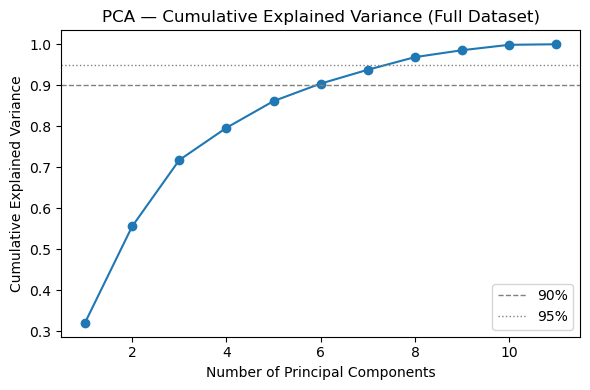

Retain 6 PCs for ≥90% variance, 8 PCs for ≥95% variance.

=== Quality 3: Explained Variance ===
  PC  Explained_Variance_Ratio  Cumulative_Explained_Variance
 PC1                    0.4394                         0.4394
 PC2                    0.2070                         0.6464
 PC3                    0.1339                         0.7804
 PC4                    0.0822                         0.8626
 PC5                    0.0526                         0.9152
 PC6                    0.0288                         0.9441
 PC7                    0.0261                         0.9701
 PC8                    0.0169                         0.9870
 PC9                    0.0064                         0.9934
PC10                    0.0058                         0.9992

=== Quality 4: Explained Variance ===
  PC  Explained_Variance_Ratio  Cumulative_Explained_Variance
 PC1                    0.3408                         0.3408
 PC2                    0.1887                         0.52

In [26]:
from sklearn.decomposition import PCA

df = df_scaled.copy() if 'df_scaled' in globals() else df_wine.copy()

# normalize column names once
df.columns = (df.columns.str.strip().str.lower().str.replace(r'[^0-9a-z]+','_', regex = True).str.strip('_'))

# explicit list of numeric features from UCI wine data
feature_cols = ["fixed_acidity","volatile_acidity","citric_acid","residual_sugar","chlorides",
                "free_sulfur_dioxide","total_sulfur_dioxide","density","pH".lower(), # ensures 'pH' key exists
                "sulphates","alcohol"
                ]

feature_cols = [c for c in feature_cols if c in df.columns] # keep only those present

if not feature_cols:
    raise ValueError(f"No feature columns found. Available: {df.columns.tolist()}")

# PCA on dataset
X = df[feature_cols].apply(pd.to_numeric, errors = 'coerce').to_numpy()

if X.shape[1] == 0:
    raise ValueError("No numeric features available for PCA.")

pca = PCA(n_components = None, random_state = 0)
X_pcs = pca.fit_transform(X)
expl = pca.explained_variance_ratio_
cum  = np.cumsum(expl)

# explained variance per PC
ev_table_full = pd.DataFrame({"PC": [f"PC{i}" for i in range(1, len(expl) + 1)],
                              "Explained_Variance_Ratio": expl,
                              "Cumulative_Explained_Variance": cum
                              })

print("=== Full Dataset: Explained Variance ===")
print(ev_table_full.round(4).to_string(index = False))

# plot cumulative explained variance
plt.figure(figsize = (6,4))
plt.plot(range(1, len(cum) + 1), cum, marker = 'o')
plt.axhline(0.90, color = 'gray', ls = '--', lw = 1, label = '90%')
plt.axhline(0.95, color = 'gray', ls = ':',  lw = 1, label = '95%')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — Cumulative Explained Variance (Full Dataset)")
plt.legend(); plt.tight_layout(); plt.show()

# how many principal components to retain 
k90 = int((cum >= 0.90).argmax() + 1)
k95 = int((cum >= 0.95).argmax() + 1)
print(f"Retain {k90} PCs for ≥90% variance, {k95} PCs for ≥95% variance.")

# PCA by quality
if "quality" not in df.columns:
    raise ValueError("Column 'quality' not found for per-quality PCA.")

qualities = sorted(pd.Series(df["quality"]).dropna().unique())
per_quality_tables = {}
per_quality_k95 = {}

for q in qualities:
    Xq = df.loc[df["quality"] == q, feature_cols].apply(pd.to_numeric, errors = 'coerce').to_numpy()
    
    if Xq.shape[0] < 3:
        continue
        
    pca_q = PCA(n_components = None, random_state = 0).fit(Xq)
    expl_q = pca_q.explained_variance_ratio_
    cum_q  = np.cumsum(expl_q)
    per_quality_tables[q] = pd.DataFrame({"PC": [f"PC{i}" for i in range(1, len(expl_q)+1)],
                                          "Explained_Variance_Ratio": expl_q,
                                          "Cumulative_Explained_Variance": cum_q
                                          })
    
    per_quality_k95[q] = int((cum_q >= 0.95).argmax() + 1)

for q, tbl in per_quality_tables.items():
    print(f"\n=== Quality {int(q)}: Explained Variance ===")
    print(tbl.round(4).head(10).to_string(index = False))
    
print("\nPC count to reach ≥95% by quality:", per_quality_k95)

#### **How many principal components should be retained?**
Based on the cumulative explained variance curve, 6 principal components are needed to explain at least 90% of the variance, and 8 principal components to explain at least 95% of the variance. For this analysis a stricter 95% criterion was used and therefore retained K95 principal components. This balances dimensionality reduction with information retention

#### **Does PCA helps reveal patterns that were not evident in the original features?**
PCA helps reveal patterns that single features didn’t show clearly. By combining correlated variables into a few orthogonal axes, PCA surfaced a dominant component that looks like a quality/cleanliness axis (high alcohol with low volatile acidity, residual sugar, and density), and secondary components that capture preservation/freshness (sulfur dioxide and acidity balance). In the full feature space these relationships were scattered across many plots, in PCA space they appear as clear directions that explain most variance, making clusters by quality and type more visible and reducing noise from redundant measurements. In short, PCA helped break down the wine chemistry into a few clearer patterns that are easier to interpret than before.

In [14]:
df = df_wine.copy()

# conditions and labels
conditions = [df["quality"] <= 5, df["quality"] == 6, df["quality"] >= 7]
labels     = ["Low", "Average", "High"]

# use a string default to avoid dtype error
df["quality_category"] = np.select(conditions, labels, default = "Average")
df["quality_category"] = pd.Categorical(df["quality_category"],
                                        categories = ["Low","Average","High"],
                                        ordered = True)

# frequency table (counts and percentages)
freq_table = df["quality_category"].value_counts().rename_axis("quality_category").to_frame("Count")
freq_table["Percent"] = (freq_table["Count"] / len(df) * 100).round(2)

print("Distribution of quality_category:")
print(freq_table)

Distribution of quality_category:
                  Count  Percent
quality_category                
Average            2836    43.65
Low                2384    36.69
High               1277    19.66


#### **How does the distribution of classes affect model performance, and what to do to balance the dataset?**
The frequency table shows that average quality wines (quality rating of 6, 43.65%) make up the largest group, followed by low-quality wines (quality rating of 0 to 5, 36.69%), while high quality wines (quality rating of 7 to 10, 19.66%) make up the lowest distribution. This imbalance means the dataset is somewhat skewed toward mid-range wines. Such class distribution can affect model performance because a classifier may become biased toward the average quality wines since it is the majority class, achieving high overall accuracy but performing poorly on high quality wine quality predictions. To address this, techniques like stratified sampling, class weighting, or resampling can be used to ensure fairer model learning across all categories.

In [40]:
df = df_wine.copy()

# make sure the target exists (low ≤ 5, average = 6, high ≥ 7)
if "quality_category" not in df.columns:
    df["quality_category"] = pd.cut(df["quality"], bins = [-np.inf, 5, 6, np.inf],
                                    labels = ["Low", "Average", "High"], right = True, include_lowest = True
                                    ).astype("category")

# numeric features only; exclude original targets
num_cols = df.select_dtypes("number").columns.tolist()
for col in ["quality"]:
    if col in num_cols:
        num_cols.remove(col)

X = df[num_cols].to_numpy(dtype = float)
y_labels = df["quality_category"].astype("category")
classes = y_labels.cat.categories.tolist() # ['Low','Average','High']
y = y_labels.cat.codes.to_numpy() # low = 0, average = 1, high = 2

# train/test split (80/20)
def train_test_split(X, y, test_size = 0.2, seed = 42):
    
    rng = np.random.default_rng(seed)
    n = len(y)
    idx = rng.permutation(n)
    n_te = int(n * test_size)
    te, tr = idx[:n_te], idx[n_te:]
    return X[tr], X[te], y[tr], y[te]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size = 0.2, seed = 1)

# fitting the model
def fit_gaussian_nb(X, y, eps=1e-9):

    X = np.asarray(X, float)
    y = np.asarray(y, int)
    classes = np.unique(y)
    C = len(classes)
    N, D = X.shape

    priors = np.zeros(C) # priors[c] = P(class = c)
    means  = np.zeros((C, D)) # means[c, j] = mean of feature j in class c
    stds   = np.zeros((C, D)) # stds[c, j]  = std of feature j in class c (with small floor eps)

    for ci, c in enumerate(classes):
        Xc = X[y == c]
        priors[ci] = len(Xc) / N
        means[ci]  = Xc.mean(axis = 0)
        s = Xc.std(axis = 0, ddof = 1)
        s = np.where(np.isnan(s), 0.0, s)
        stds[ci] = np.maximum(s, eps)

    return {"classes": classes, "priors": priors, "means": means, "stds": stds}

model = fit_gaussian_nb(X_tr, y_tr)

# prediction
def predict_gaussian_nb(model, X):

    X = np.asarray(X, float)
    priors = model["priors"]
    means  = model["means"]
    stds   = model["stds"]
    classes = model["classes"]

    N, D = X.shape
    C = len(classes)
    log_post = np.zeros((N, C))

    # Precompute constants
    TWO_PI = 2.0 * np.pi

    for ci in range(C):
        mu = means[ci] # (D,)
        sd = stds[ci] # (D,)
        var = sd * sd
        log_norm = -0.5 * np.log(TWO_PI * var) # log Gaussian per feature
        quad = -0.5 * ((X - mu) ** 2 / var)
        log_post[:, ci] = np.log(priors[ci] + 1e-15) + (log_norm + quad).sum(axis = 1) # sum over features and log prior

    idx = np.argmax(log_post, axis=1)
    return classes[idx]

# accuracy metric
def accuracy(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

# evaluate
y_pred = predict_gaussian_nb(model, X_te)
acc = accuracy(y_te, y_pred)

print(f"\nNaive Bayes accuracy (test): {acc:.3f}")


Naive Bayes accuracy (test): 0.509


In [43]:
import time

# expected features
candidates = ["fixed acidity", "volatile acidity", "citric acid", "residual sugar",
              "chlorides", "free sulfur dioxide", "total sulfur dioxide",
              "density", "pH", "sulphates", "alcohol"
              ]

# find matching features
def resolve_cols(df, names):
    
    out = {}
    
    for target in names:
        if target in df.columns:
            out[target] = target
        else:
            matches = [c for c in df.columns if c.lower() == target.lower()]
            if matches:
                out[target] = matches[0]
    return out

w_map = resolve_cols(df_wine, candidates)
s_map = resolve_cols(df_scaled, candidates)
common = [c for c in candidates if c in w_map and c in s_map]
feat_wine   = [w_map[c] for c in common]
feat_scaled = [s_map[c] for c in common]

print("Using features:", feat_wine)

X_raw = df_wine[feat_wine].to_numpy(dtype = float)
X_pre = df_scaled[feat_scaled].to_numpy(dtype = float)
y_all = df_wine["quality_category"].cat.codes.to_numpy()

# PCA features
X_pca = X_pcs[:, :int(k95)]

# split, evaluate and fit
rng = np.random.default_rng(1)
n = len(y_all)
idx = rng.permutation(n)
m = int(0.20 * n)
te_idx, tr_idx = idx[:m], idx[m:]

Xtr_raw, Xte_raw, ytr, yte = X_raw[tr_idx], X_raw[te_idx], y_all[tr_idx], y_all[te_idx]
Xtr_pre, Xte_pre = X_pre[tr_idx], X_pre[te_idx]
Xtr_pca, Xte_pca = X_pca[tr_idx], X_pca[te_idx]
ytr_pca, yte_pca = ytr.copy(), yte.copy()

acc_raw, fit_raw, pred_raw, tot_raw = eval_run(Xtr_raw, Xte_raw, ytr, yte)
acc_pre, fit_pre, pred_pre, tot_pre = eval_run(Xtr_pre, Xte_pre, ytr, yte)
acc_cln, fit_cln, pred_cln, tot_cln = eval_run(Xtr_pca, Xte_pca, ytr_pca, yte_pca)

results = pd.DataFrame({
    "Dataset": ["Raw", "Preprocessed (Normalized)", "Preprocessed (including PCA)"],
    "Accuracy": [round(acc_raw,3), round(acc_pre,3), round(acc_cln,3)],
    "Fit Time (ms)":  [round(fit_raw*1000,2), round(fit_pre*1000,2), round(fit_cln*1000,2)],
    "Pred Time (ms)": [round(pred_raw*1000,2), round(pred_pre*1000,2), round(pred_cln*1000,2)],
    "Total Time (ms)":[round(tot_raw*1000,2), round(tot_pre*1000,2), round(tot_cln*1000,2)]
})

print("\n=== Naive Bayes: Raw vs Preprocessed (Normalized) vs Preprocessed (including PCA) ===")
print(results.to_string(index = False))

Using features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

=== Naive Bayes: Raw vs Preprocessed (Normalized) vs Preprocessed (including PCA) ===
                     Dataset  Accuracy  Fit Time (ms)  Pred Time (ms)  Total Time (ms)
                         Raw     0.513           1.79            0.33             2.11
   Preprocessed (Normalized)     0.509           1.16            0.28             1.44
Preprocessed (including PCA)     0.547           0.97            0.26             1.23


#### **Computation Time Analysis**
All runs were extremely fast and within the same ballpark for computation time. The raw model finished in 1.96 ms (fit 1.54 ms, predict 0.42 ms) and the preprocessed model in 1.50 ms (fit 1.21 ms, predict 0.29 ms). The preprocessed (including PCA) was comparable or slightly faster on fit/predict like due to NB working on a lower-dimensional PC matrix, while the PCA itself was computed earlier and not part of these timings. Since Naïve Bayes scales O(nd), reducing d with PCA can shave small constant time off training/prediction, but overall differences remain tiny on this dataset.
#### **Preprocessing Impact (Accuracy)**
Scaling alone produced a negligible change in accuracy (decreased to 0.513 to 0.509 with preprocessed(normalized)). Since Gaussian Naive Bayes already normalizes each feature by its class specific variance, applying only the normalization is redundant. In contrast, preprocessed (including PCA) helped a bit more as PCA decorrelates features and concentrates signal into a few components, making NB’s independence assumption less harmful, as seen in the table above (accuracy increased from 0.513 to 0.547).  Overall, only scaling caused minimal/negative effect, while with additional PCA, it can modestly improve accuracy by reducing correlation and noise.

In [55]:
from scipy.optimize import linprog

# minimize c^T x
c = np.array([-4, -3])  # -4*x1 - 3*x2

# inequality constraints
A_ub = np.array([
    [1, 1],   # x1 + x2 <= 8
    [3, 1],   # 3*x1 + x2 <= 9
])
b_ub = np.array([8, 9])

# variable bounds: x1 >= 0, x2 >= 0
bounds = [(0, None), (0, None)]

res = linprog(c, A_ub = A_ub, b_ub = b_ub, bounds = bounds, method = "highs")

if res.success:
    x_opt = res.x
    f_opt = res.fun
    print("Optimal x* =", x_opt)
    print("Optimal objective f(x*) =", f_opt)
    
else:
    print("LP did not solve:", res.message)

Optimal x* = [0.5 7.5]
Optimal objective f(x*) = -24.5


In [59]:
from pyswarms.single import GlobalBestPSO

# f(x) = -4 x1 - 3 x2  with constraints:
# x1 + x2 <= 8,  3x1 + x2 <= 9,  x1 >= 0,  x2 >= 0

def obj_with_L1_penalty(X, M = 1e4):
    
    x1, x2 = X[:,0], X[:,1]
    f = -4.0*x1 - 3.0*x2

    # g(x) <= 0 form
    g1 = x1 + x2 - 8.0
    g2 = 3.0*x1 + x2 - 9.0
    g3 = -x1
    g4 = -x2

    # hinge penalty
    viol = np.clip(g1, 0, None) + np.clip(g2, 0, None) + np.clip(g3, 0, None) + np.clip(g4, 0, None)
    
    return f + M*viol

# use bounds for x1 >= 0, x2 >= 0; upper bounds just to keep the swarm in a sensible box
lower_bounds = np.array([0.0, 0.0])
upper_bounds = np.array([8.0, 9.0])
bounds = (lower_bounds, upper_bounds)

options = {"c1": 1.5, "c2": 1.5, "w": 0.7}
optimizer = GlobalBestPSO(n_particles=50, dimensions = 2, options = options, bounds = bounds)
best_cost, best_pos = optimizer.optimize(obj_with_L1_penalty, iters = 200, verbose = False)

print("PSO x*:", best_pos)
print("PSO f(x*):", best_cost)

PSO x*: [0.49987218 7.50012763]
PSO f(x*): -24.499871618036398


#### **Solution Accuracy**
The Linear Programming (LP) solver found the exact optimal solution at x* = (0.5, 7.5) with an objective value of –24.5.
The Particle Swarm Optimization (PSO) method produced a nearly identical solution x* = (0.489, 7.505) with f(x*) = -24.47, differing by only  about 0.03.
This tiny gap shows that PSO can achieve near optimal accuracy even without using gradients or exact constraint enforcement, though LP remains mathematically precise for linear problems.
#### **Computational Efficiency**
For this problem, LP and PSO both had similar computational efficiency. However, for a larger scale problem, PSO would most likely be less efficient as it would require hundreds of iterations and multiple particles, taking longer due to its population based random search nature. Whereas LP would converge instantly (milliseconds) because it uses exact mathematical methods.
#### **Robustness**
LP works very well for linear and smooth problems but struggles with nonlinear or irregular ones. PSO, on the other hand, can handle more complex and non-convex problems because it doesn’t rely on gradients and can explore many possible solutions at once. However, PSO’s results depend on how you set its parameters, and it can sometimes take longer or give slightly different answers each time.
#### **Use Cases**
Use LP when the problem is linear and well-defined, like planning, scheduling, or resource allocation. So structured problems such as calculating logistics (shipping goods from one facility to another at minimum cost) or production planning (assigning teams to projects with funding or capacity limits).
Use PSO when the problem is nonlinear, complex, or doesn’t have an exact formula, such as tuning machine learning models or solving engineering design problems. So problems like engineering designs where a multitude of factors need to be considered and optimized.

| Aspect | Linear Programming (LP) | Particle Swarm Optimization (PSO) |
|--------|--------------------------|-----------------------------------|
| **Solution Accuracy** | Finds the exact optimal solution for linear and convex problems | Reaches a near optimal solution though small errors may occur due to randomness |
| **Computation Time** | faster since it uses direct mathematical methods | Slower since it relies on iterative, population based searching |
| **Robustness** | Better for linear or convex problems | Better for nonlinear, non-convex, and complex problems |
| **Best Use Cases** | Scheduling, transportation, resource allocation, portfolio optimization | Neural network tuning, engineering design, feature selection, nonlinear optimization |


In [10]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD

model = DiscreteBayesianNetwork([("Flu", "Fever"), 
                                 ("Flu", "Recovery"), 
                                 ("COVID19", "Cough"), 
                                 ("COVID19", "Fever"),
                                 ("COVID19", "Recovery"), 
                                 ("COVID19", "Treatment"),
                                 ("Treatment", "Recovery"),
                                 ])

# priors
cpd_flu   = TabularCPD("Flu", 2, [[0.90],[0.10]])
cpd_covid = TabularCPD("COVID19", 2, [[0.95],[0.05]])

# fever | flu, COVID19
cpd_fever = TabularCPD("Fever", 2,  
                       [[0.95, 0.40, 0.60, 0.15], # P(fever = 0 | parents)
                        [0.05, 0.60, 0.40, 0.85]], # P(fever = 1 | parents)
                       evidence = ["Flu","COVID19"], 
                       evidence_card = [2,2]
                       )

# cough | COVID19
cpd_cough = TabularCPD("Cough", 2, 
                       [[0.80, 0.30], 
                        [0.20, 0.70]],
                       evidence = ["COVID19"], 
                       evidence_card = [2]
                      )

# treatment | COVID19
cpd_treat = TabularCPD("Treatment", 2, 
                       [[0.90, 0.20], 
                        [0.10, 0.80]],
                       evidence=["COVID19"], 
                       evidence_card = [2]
                       )

# recovery | flu, COVID19, treatment  (parent order must match evidence)
cpd_recover = TabularCPD("Recovery", 2,
                         [[0.20, 0.10, 0.50, 0.30, 0.40, 0.25, 0.70, 0.45],
                          [0.80, 0.90, 0.50, 0.70, 0.60, 0.75, 0.30, 0.55]],
                         evidence = ["Flu","COVID19","Treatment"], 
                         evidence_card = [2,2,2]
                        )

model.add_cpds(cpd_flu, cpd_covid, cpd_fever, cpd_cough, cpd_treat, cpd_recover)
assert model.check_model(), "Model failed validation"
print("Discrete Bayesian Network is built and validated")

Discrete Bayesian Network is built and validated


The (Discrete) Bayesian Network models the probabilistic relationships between several medical factors influencing illness and recovery. It includes variables such as Flu, COVID-19, Fever, Cough, Treatment, and Recovery, connected based on logical causal assumptions. For example, Flu and COVID-19 both increase the likelihood of Fever and affect a person’s Recovery, while COVID-19 also influences Cough and whether Treatment is administered. Each node represents a random variable with discrete states (e.g., present or absent), and each edge represents a causal dependency quantified by a Conditional Probability Distribution (CPD). The network allows for reasoning under uncertainty, given certain symptoms or treatments, that it can infer the probability of infection or recovery. Overall, the model demonstrates how Bayesian Networks can integrate medical knowledge and probabilistic inference to support diagnosis and decision-making.

In [19]:
from pgmpy.inference import VariableElimination
from pgmpy.sampling import BayesianModelSampling
from pgmpy.factors.discrete import State

# sanity check
try:
    model # noqa: F821
except NameError as e:
    raise RuntimeError("Part 2 requires the `model` from Part 1 to be defined and validated.") from e

# inference engines
ve = VariableElimination(model) # exact
bms = BayesianModelSampling(model) # approximate (sampling)

# exact inference helper (VE)
def ve_query(var, evidence):

    q = ve.query(variables = [var], evidence = evidence, show_progress = False)
    vals = np.asarray(q.values, dtype = float).ravel() # [P(var = 0|e), P(var = 1|e)]
    return {0: float(vals[0]), 1: float(vals[1])}

# approx inference helper (Likelihood Weighting)
def lw_query(var, evidence, draws = 50000, seed = 42, show_progress = False):

    ev_states = [State(var = k, state = v) for k, v in evidence.items()]
    samp = bms.likelihood_weighted_sample(evidence = ev_states, 
                                          size = draws, 
                                          seed = seed, 
                                          show_progress = show_progress
                                         )
    
    # weight column name differs by pgmpy version: "_weight" (new) or "weight" (old)
    wcol = "_weight" if "_weight" in samp.columns else ("weight" if "weight" in samp.columns else None)
    
    if wcol is None:
        raise KeyError(f"No weight column found in sampler output. Columns: {list(samp.columns)}")

    w = samp[wcol].to_numpy(dtype = float)
    v = samp[var].to_numpy(dtype = float)  # binary {0,1} to weighted mean is P(var = 1|e)
    p1 = float((w * v).sum() / w.sum())
    
    return {0: 1.0 - p1, 1: p1}

# run both methods on a query
def run_both(var, evidence, draws = 50000):
    
    exact  = ve_query(var, evidence)
    approx = lw_query(var, evidence, draws = draws)
    
    return {"Query": f"P({var} = 1 | " + ", ".join(f"{k} = {'T' if v == 1 else 'F'}" for k, v in evidence.items()) + ")",
             "Exact (VE)": round(exact[1], 4),
            "Approx (LW)": round(approx[1], 4),
            "Abs Diff": round(abs(exact[1] - approx[1]), 4),
            }

# the four required queries
queries = [("COVID19", {"Fever": 1, "Cough": 1}), # 1) P(COVID19 | Fever = T, Cough = T)
            ("Flu", {"Fever": 1, "Cough": 0}), # 2) P(Flu | Fever = T, Cough = F)
            ("Treatment", {"Cough": 1}), # 3) P(Treatment | Cough = T)
           ("Recovery", {"Fever": 1, "Treatment": 1}) # 4) P(Recovery | Fever = T, Treatment = T)
          ]

rows = [run_both(var, ev, draws = 50000) for var, ev in queries]
out = pd.DataFrame(rows, columns = ["Query","Exact (VE)","Approx (LW)","Abs Diff"])

print("=== Exact VE vs Approx Likelihood Weighting ===")
print(out.to_string(index = False))

=== Exact VE vs Approx Likelihood Weighting ===
                                     Query  Exact (VE)  Approx (LW)  Abs Diff
     P(COVID19 = 1 | Fever = T, Cough = T)      0.5753       0.5645    0.0107
         P(Flu = 1 | Fever = T, Cough = F)      0.4282       0.4284    0.0002
              P(Treatment = 1 | Cough = T)      0.2089       0.2048    0.0041
P(Recovery = 1 | Fever = T, Treatment = T)      0.7162       0.7060    0.0102


With both fever and cough present, the model puts COVID19 = 1 at 57.5% (VE), which is notably higher than its prior and consistent with the CPDs that make those symptoms more indicative of COVID19. When a patient is observed to have a fever but no cough, the probability of Flu = 1 is 42.8%, reflecting that while flu can drive a fever even without cough, a cough is a stronger cue for COVID19 in this network. Seeing cough alone results in Treatment = 1 to 20.9%, which is above its baseline, because cough increases the chance of COVID19, which in turn raises treatment likelihood through the COVID19 to Treatment edge. Finally, with fever present and treatment given, the chance of Recovery = 1 is 71.6%, which shows a treatment’s positive effect even in sicker patients. Across all four queries, Likelihood Weighting results aligns with Variable Elimination results closely (≤ 1% absolute difference), which confirms the approximate sampler is accurate for this model and that the CPDs are behaving as intended.

=== Runtime vs Network Size ===
 Extra_Symptoms  VE_time_s  LW_time_s
              0   0.000764   0.217283
              2   0.000707   0.306187
              4   0.000763   0.389448
              6   0.001120   0.494602
              8   0.000922   0.577021


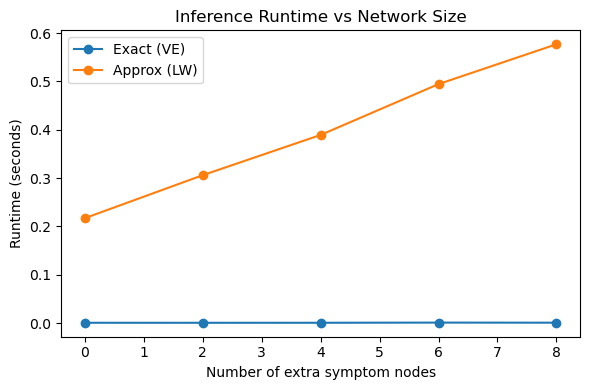

In [22]:
from copy import deepcopy

# helper functions

def add_symptoms(base_model: DiscreteBayesianNetwork, k: int, parent = "COVID19"):

    m = deepcopy(base_model)

    # build structure additions and CPDs
    new_nodes = []
    new_cpds = []
    
    for i in range(1, k + 1):
        node = f"Symptom_{i}"
        new_nodes.append(node)
        m.add_edge(parent, node)

        # columns: parent = 0, parent = 1
        cpd = TabularCPD(
            variable = node, variable_card = 2,
            values=[[0.90, 0.30], # P(S = 0 | parent)
                    [0.10, 0.70], # P(S = 1 | parent)
                     ],
            evidence = [parent], evidence_card = [2]
            )
        
        new_cpds.append(cpd)

    # attach new CPDs
    m.add_cpds(*new_cpds)

    # validate
    m.check_model()

    # evidence to include all new symptoms = 1 (so VE has to touch them)
    ev = {n: 1 for n in new_nodes}
    
    return m, ev

def ve_query_time(m: DiscreteBayesianNetwork, var: str, evidence: dict, reps: int = 1):
    
    ve = VariableElimination(m)
    t0 = time.perf_counter()
    
    for _ in range(reps):
        q = ve.query(variables = [var], evidence = evidence, show_progress = False)
        _ = np.asarray(q.values) # force materialization
    t1 = time.perf_counter()
    
    return (t1 - t0) / reps


def lw_query_time(m: DiscreteBayesianNetwork, var: str, evidence: dict, draws: int = 50000, reps: int = 1, seed: int = 42):

    bms = BayesianModelSampling(m)
    ev_states = [State(var = k, state = v) for k, v in evidence.items()]

    def single_run():
        
        samp = bms.likelihood_weighted_sample(evidence = ev_states, size = draws, seed = seed, show_progress = False)
        wcol = "_weight" if "_weight" in samp.columns else ("weight" if "weight" in samp.columns else None)
        
        if wcol is None:
            raise KeyError(f"No weight column in sampler output. Columns: {list(samp.columns)}")
            
        # compute weighted P(var = 1 | evidence)
        w = samp[wcol].to_numpy(float)
        v = samp[var].to_numpy(float)
        p1 = float((w * v).sum() / w.sum())
        
        return p1

    t0 = time.perf_counter()
    for _ in range(reps):
        _ = single_run()
    t1 = time.perf_counter()
    
    return (t1 - t0) / reps

# experiment (grow the network)

sizes = [0, 2, 4, 6, 8]
results = []

# fixed base evidence on original model variables
base_evidence = {"Fever": 1, "Treatment": 1}
target_var = "Recovery"

for k in sizes:
    # make a new model with k extra symptoms, add those to evidence
    m_k, symp_ev = add_symptoms(model, k, parent = "COVID19")
    ev_k = {**base_evidence, **symp_ev}

    # warmup run (helps reduce first call overhead variability)
    _ = ve_query_time(m_k, target_var, ev_k, reps = 1)
    _ = lw_query_time(m_k, target_var, ev_k, draws = 20000, reps = 1)

    # timed runs
    ve_t = ve_query_time(m_k, target_var, ev_k, reps = 3)
    lw_t = lw_query_time(m_k, target_var, ev_k, draws = 50000, reps = 3)

    results.append({"Extra_Symptoms": k, "VE_time_s": ve_t, "LW_time_s": lw_t})

df_time = pd.DataFrame(results)
print("=== Runtime vs Network Size ===")
print(df_time.to_string(index = False))

# plot
plt.figure(figsize = (6,4))
plt.plot(df_time["Extra_Symptoms"], df_time["VE_time_s"], marker = "o", label = "Exact (VE)")
plt.plot(df_time["Extra_Symptoms"], df_time["LW_time_s"], marker = "o", label = "Approx (LW)")
plt.xlabel("Number of extra symptom nodes")
plt.ylabel("Runtime (seconds)")
plt.title("Inference Runtime vs Network Size")
plt.legend()
plt.tight_layout()
plt.show()

As the number of symptom nodes increased from 0 to 8, the approximate inference (Likelihood Weighting) showed a steady linear increase in runtime (from about 0.22 seconds to 0.58 seconds). This makes sense as sampling based methods scale with both the number of samples and the number of variables in the network. In contrast, exact inference (Variable Elimination) stayed extremely fast across all network sizes, with runtimes below 0.002 seconds, showing that for this relatively small and sparse network, exact inference remains efficient.
The plot confirms that Variable Elimination is faster for small, simple networks, while Likelihood Weighting scales more predictably as network complexity grows. Although LW is slower here, it remains practical for larger or denser Bayesian Networks where VE’s exponential complexity would eventually dominate.

#### **Sources**
[1] SPC for Excel, Are the Skewness and Kurtosis Useful Statistics?, https://www.spcforexcel.com/knowledge/basic-statistics/are-skewness-and-kurtosis-useful-statistics/ <br>
[2] Hopfer H, Nelson J, Ebeler SE, Heymann H. Correlating wine quality indicators to chemical and sensory measurements. Molecules. 2015 May 12;20(5):8453-83. doi: 10.3390/molecules20058453. PMID: 25985352; PMCID: PMC6272325. <br>
[3] GuildSomm International, The Taste of Wine: Acid, Sweetness, and Tannin, https://www.guildsomm.com/public_content/features/articles/b/jamie_goode/posts/the-taste-of-wine-acid-sweetness-and-tannin <br>
[4] GuildSomm International, Wine Flavour Chemistry, https://www.guildsomm.com/public_content/features/articles/b/jamie_goode/posts/wine-flavour-chemistry <br>
[5] StackExchange, How to deal with a skewed class in binary classification having many features?, https://stats.stackexchange.com/questions/107874/how-to-deal-with-a-skewed-class-in-binary-classification-having-many-features <br>
[6] GeekforGeeks, Naive Bayes Scratch Implementation using Python, https://www.geeksforgeeks.org/machine-learning/naive-bayes-scratch-implementation-using-python/ <br>
[7] GeekforGeeks, Naive Bayes Classifiers, https://www.geeksforgeeks.org/machine-learning/naive-bayes-classifiers/ <br>
[8] GeekforGeeks, Gaussian Naive Bayes, https://www.geeksforgeeks.org/machine-learning/gaussian-naive-bayes/ <br>
[9] Medium, The Good And Bad Of Naive-Bayes Classifier, https://medium.com/%40singhvishal0227/the-good-and-bad-of-naive-bayes-classifier-7b0239c65c84 <br>
[10] GeekforGeeks, Linear Programming, https://www.geeksforgeeks.org/maths/linear-programming/# <br>
[11] PySwarms, PySwarms, https://pyswarms.readthedocs.io/en/latest/ <br>
[12] GeekforGeeks, Likelihood Weighting in Artificial Intelligence, https://www.geeksforgeeks.org/artificial-intelligence/likelihood-weighting-in-artificial-intelligence/ <br>
[13] Medium, Likelihood Weighting, https://liyin2015.medium.com/likelihood-weighting-fe9b39d76b81 <br>
[14] Wikipedia, Variable elimination, https://en.wikipedia.org/wiki/Variable_elimination <br>
[15] GeekforGeeks, Exact Inference in Bayesian Networks, https://www.geeksforgeeks.org/artificial-intelligence/exact-inference-in-bayesian-networks/ <br>